<a href="https://colab.research.google.com/github/ayodelenaomii/Worksite-Safety-Monitoring-with-Deep-Learning/blob/main/Worksite_Safety_Monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LOAD DATA

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models


img_size = 255
batch_size= 32
num_classes = 2


dataset_dir = '/content/drive/MyDrive/Worksite-Safety-Monitoring-Dataset'



# Load the training data
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=dataset_dir + '/train',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(img_size, img_size),
    shuffle=True,
    seed=42
)

# Load the validation data
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=dataset_dir + '/valid',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(img_size, img_size),
    shuffle=True,
    seed=42
)

# Load the test data
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=dataset_dir + '/test',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=(img_size, img_size),
    shuffle=True,
    seed=42
)



Found 1620 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


Sample of Data

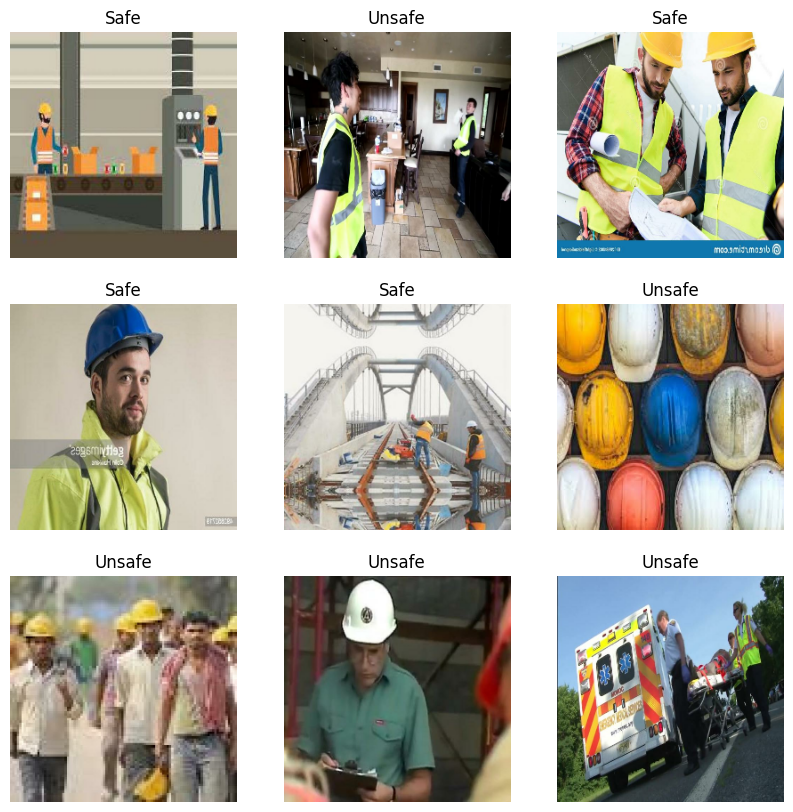

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Safe" if labels[i] == 0 else "Unsafe")
        plt.axis("off")
plt.show()


DATA AUGMENTATION

In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

NORMALIZATION

In [5]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization, Dense
model = keras.Sequential()
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)
train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)


MODELLING

In [7]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_size, img_size, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(epsilon=0.01),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)




In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_binary_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stopping]
)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 387s 7s/step - binary_accuracy: 0.5100 - loss: 0.6936 - val_binary_accuracy: 0.5000 - val_loss: 0.6936
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 414s 7s/step - binary_accuracy: 0.5204 - loss: 0.6917 - val_binary_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 368s 7s/step - binary_accuracy: 0.5052 - loss: 0.6925 - val_binary_accuracy: 0.5000 - val_loss: 0.6923
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 357s 7s/step - binary_accuracy: 0.5398 - loss: 0.6901 - val_binary_accuracy: 0.5000 - val_loss: 0.6988
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 377s 7s/step - binary_accuracy: 0.5166 - loss: 0.6929 - val_binary_accuracy: 0.5150 - val_loss: 0.6893
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 349s 7s/step - binary_accuracy: 0.5397 - loss: 0.6864 - val_binary_accuracy: 0.5050 - val_loss: 0.6975
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 331s 6s/step - binary_accuracy: 0.5628 - loss: 0.6830 - val_binary_accuracy: 0.5900 - val_loss: 0.6761
Epoch 8/50
51

MODEL EVALUATION

In [10]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - binary_accuracy: 0.7058 - loss: 0.5863
Test Accuracy: 67.50%
Test Loss: 0.5999


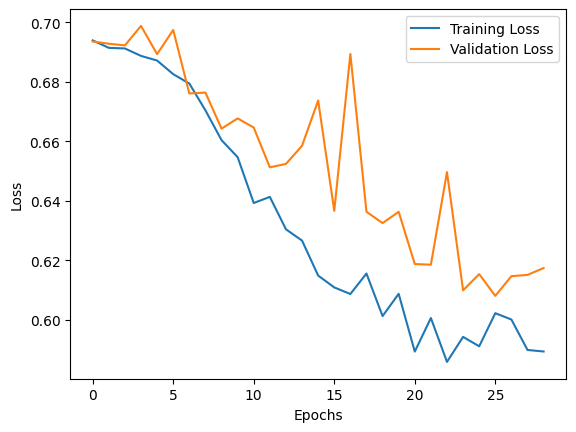

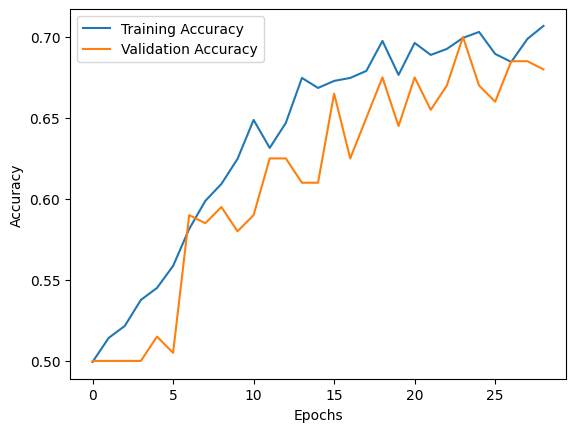

In [23]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [20]:
model.save('my_first_model.keras')

In [17]:
from tensorflow.keras.models import load_model

loaded_model = load_model('my_first_model.keras')


MODEL TEST

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


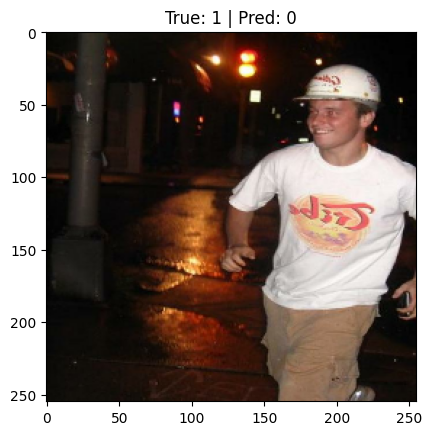

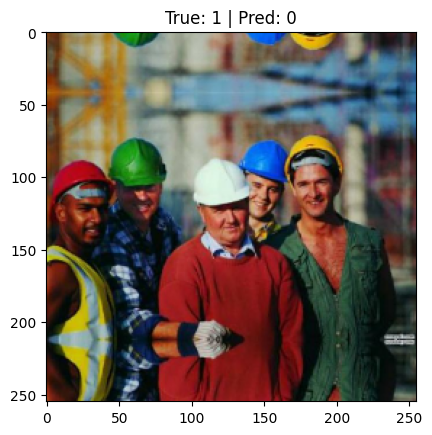

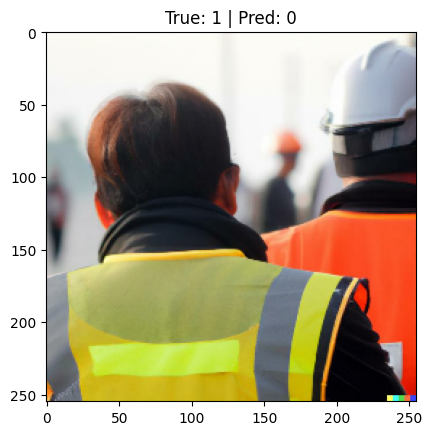

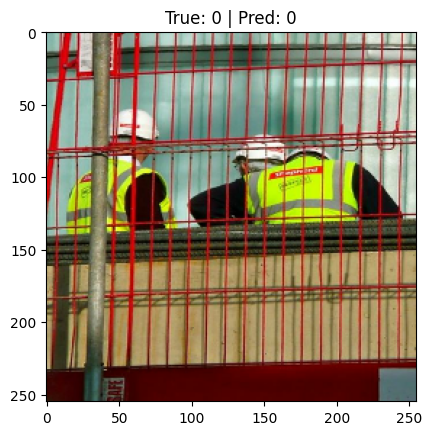

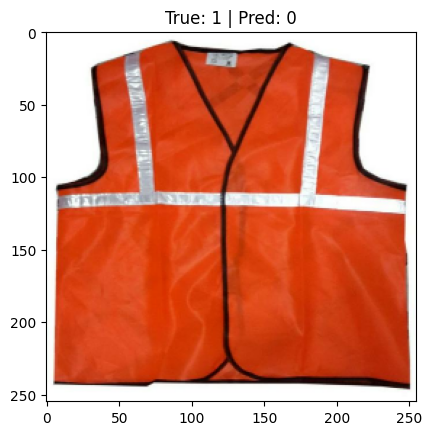

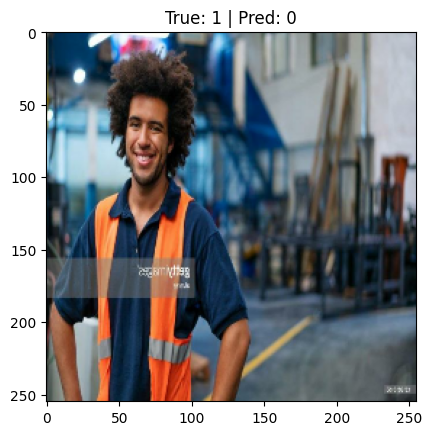

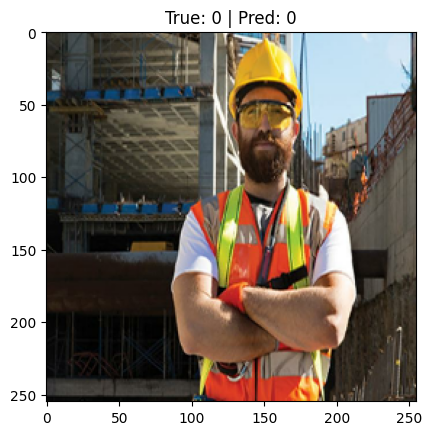

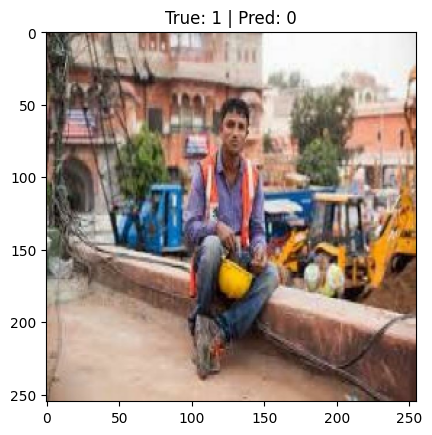

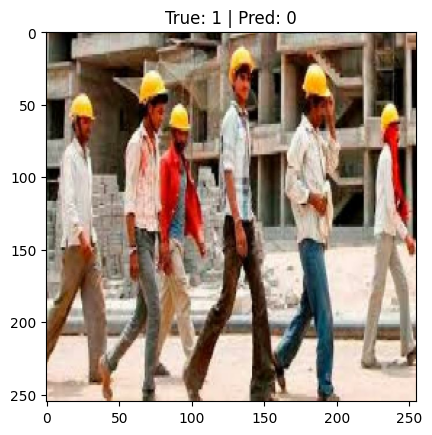

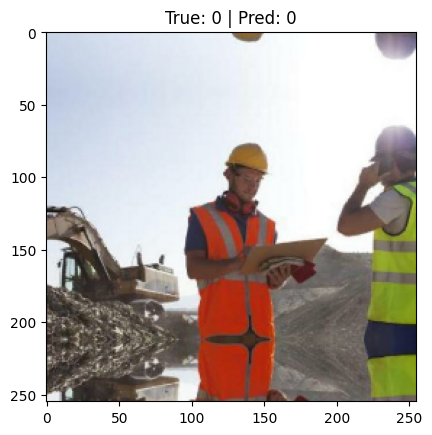

In [18]:

images, labels = next(iter(test_data))

predictions = loaded_model.predict(images)
predicted_classes = tf.argmax(predictions, axis=1)

for i in range(10):
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"True: {labels[i].numpy()} | Pred: {predicted_classes[i].numpy()}")
    plt.show()


In [19]:

loaded_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 255, 255, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 253, 253, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 126, 126, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 124, 124, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │      12,845,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,701,957 (151.45 MB)

 Trainable params: 13,233,985 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,467,972 (100.97 MB)